In [29]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression,SGDRegressor
from sklearn.preprocessing import PolynomialFeatures,StandardScaler
from sklearn.metrics import r2_score
from sklearn.pipeline import Pipeline

In [30]:
df = pd.read_csv("Ice Cream Sales - temperatures.csv")

In [31]:
df

,Temperature,Ice Cream Profits
0,39,13.17
1,40,11.88
2,41,18.82
3,42,18.65
4,43,17.02
...,...,...
360,99,85.13
361,99,87.08
362,99,89.29
363,101,81.91


In [32]:
df.shape


(365, 2)

In [33]:
df.isnull().sum()

Temperature          0
Ice Cream Profits    0
dtype: int64

In [34]:
df.duplicated().sum()

np.int64(1)

In [35]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 365 entries, 0 to 364
Data columns (total 2 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Temperature        365 non-null    int64  
 1   Ice Cream Profits  365 non-null    float64
dtypes: float64(1), int64(1)
memory usage: 5.8 KB


In [36]:
df[df.duplicated()]

,Temperature,Ice Cream Profits
227,77,56.33


In [37]:
df=df.drop_duplicates()

In [38]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 364 entries, 0 to 364
Data columns (total 2 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Temperature        364 non-null    int64  
 1   Ice Cream Profits  364 non-null    float64
dtypes: float64(1), int64(1)
memory usage: 8.5 KB


In [39]:
df.describe()

,Temperature,Ice Cream Profits
count,364.000000,364.000000
mean,71.967033,52.092005
std,13.274139,16.009471
min,39.000000,11.880000
25%,63.000000,40.635000
50%,73.000000,53.605000
75%,82.000000,63.727500
max,101.000000,89.290000


<function matplotlib.pyplot.show(close=None, block=None)>

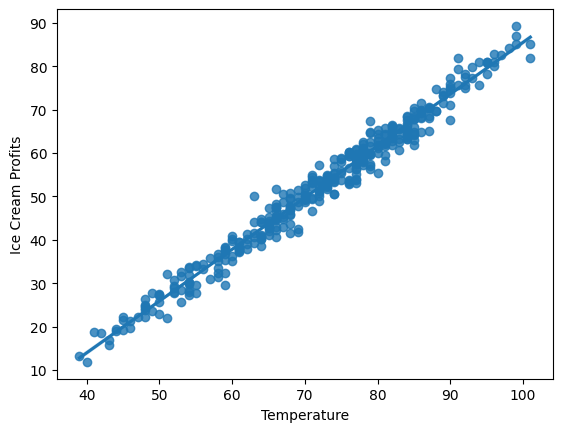

In [40]:
sns.regplot(x='Temperature', y='Ice Cream Profits', data=df)
plt.show

<function matplotlib.pyplot.show(close=None, block=None)>

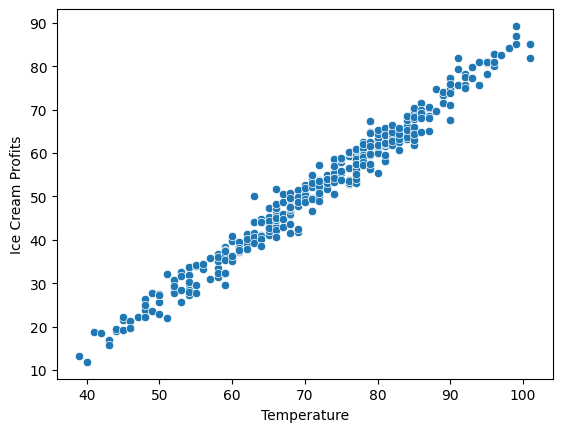

In [41]:
sns.scatterplot(x='Temperature', y='Ice Cream Profits', data=df)
plt.show

<Axes: >

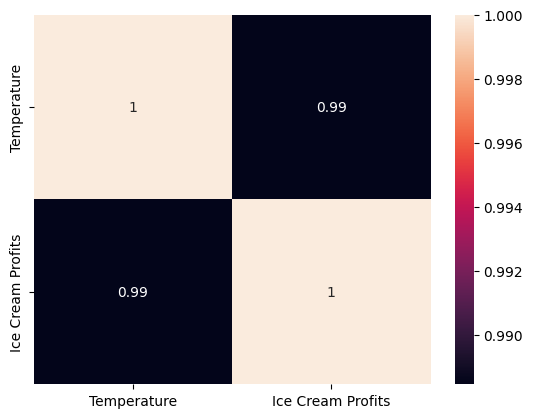

In [42]:
sns.heatmap(df.corr(), annot=True)

In [43]:
X=df.drop(columns="Ice Cream Profits")
y=df["Ice Cream Profits"]

In [44]:
X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.3, random_state=42)

In [45]:
X_train.shape

(254, 1)

In [46]:
y_train.shape

(254,)

In [47]:
lr=LinearRegression()
lr.fit(X_train,y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [48]:
lr.score(X_train,y_train)

0.9729782858783471

In [49]:
y_pred = lr.predict(X_test)

In [50]:
y_test.values

array([53.95, 29.39, 24.68, 77.18, 31.56, 54.08, 38.21, 47.36, 50.31,
       46.04, 57.47, 33.58, 64.22, 33.44, 46.9 , 68.54, 13.17, 58.72,
       73.16, 47.36, 22.34, 55.04, 39.69, 75.94, 67.42, 57.1 , 59.87,
       60.75, 81.91, 87.08, 27.64, 44.31, 33.71, 80.75, 54.26, 44.48,
       38.47, 22.89, 75.58, 80.98, 69.19, 56.34, 28.05, 64.36, 42.71,
       61.22, 40.59, 36.79, 15.88, 27.99, 60.46, 65.49, 62.58, 75.04,
       52.13, 74.8 , 40.28, 18.65, 84.12, 37.3 , 65.4 , 59.91, 39.53,
       30.37, 63.63, 40.95, 55.07, 48.65, 58.85, 37.66, 41.21, 54.28,
       68.28, 53.48, 79.31, 65.2 , 38.1 , 41.44, 80.97, 23.78, 32.29,
       67.58, 19.57, 47.68, 44.98, 65.19, 67.97, 65.12, 67.93, 43.03,
       64.02, 32.39, 52.05, 61.85, 45.89, 73.94, 43.73, 26.41, 49.46,
       27.29, 55.34, 74.69, 82.83, 59.94, 47.73, 54.59, 59.62, 85.13,
       59.41, 57.06])

In [51]:
r2_score(y_test, y_pred)

0.983948406682567

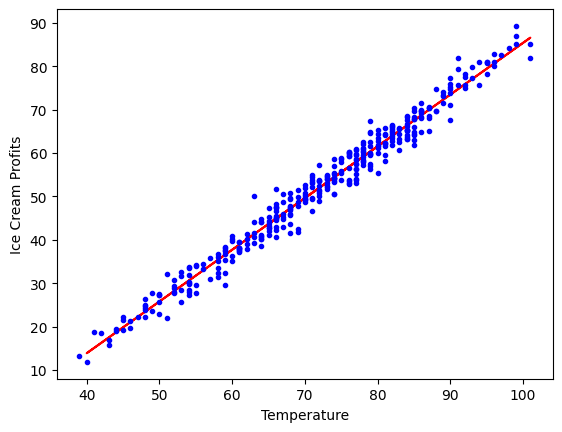

In [52]:
plt.plot(X_train,lr.predict(X_train),color="r")
plt.plot(X,y,"b.")
plt.xlabel("Temperature")
plt.ylabel("Ice Cream Profits")
plt.show()

In [115]:
poly = PolynomialFeatures(degree=20, include_bias=True)
X_train_trans = pd.DataFrame(poly.fit_transform(X_train),columns = poly.get_feature_names_out(X_train.columns))
X_test_trans = pd.DataFrame(poly.transform(X_test), columns = poly.get_feature_names_out(X_test.columns))

In [116]:
print(X_train["Temperature"])


269    81
233    78
157    71
19     48
147    69
       ..
71     60
106    65
271    82
349    94
102    65
Name: Temperature, Length: 254, dtype: int64


In [117]:
print(X_train_trans["Temperature^2"])
# print(type(X_train_trans))
# print(X_train_trans.columns)

0      6561.0
1      6084.0
2      5041.0
3      2304.0
4      4761.0
        ...  
249    3600.0
250    4225.0
251    6724.0
252    8836.0
253    4225.0
Name: Temperature^2, Length: 254, dtype: float64


In [118]:
X_train_trans.shape

(254, 21)

In [119]:
lr = LinearRegression()
lr.fit(X_train_trans, y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [120]:
y_pred = lr.predict(X_test_trans)

In [121]:
r2_score(y_test, y_pred)

0.9531065703718562

In [122]:
print(lr.coef_)
print(lr.intercept_)

[ 0.00000000e+00  2.75169401e-31  5.14513009e-34 -7.10935034e-38
  4.17348722e-41 -1.43492962e-42  4.58411398e-43  2.93551201e-41
  1.79803090e-39  1.05456289e-37  5.88625627e-36  3.09385638e-34
  1.50554212e-32  6.59822521e-31  2.48165053e-29  7.27043203e-28
  1.27963666e-26 -5.42578170e-28  8.63204062e-30 -6.10842184e-32
  1.62185061e-34]
27.656193020461117


In [123]:
X_train.min()
# X_train.max()

Temperature    40
dtype: int64

In [124]:
X_new = np.linspace(40, 101, 200).reshape(200,1)
# X_train_trans = pd.DataFrame(poly.fit_transform(X_train),columns = poly.get_feature_names_out(X_train.columns))
X_new_poly = pd.DataFrame(poly.fit_transform(X_new),columns=poly.get_feature_names_out(X_train.columns))
y_new = lr.predict(X_new_poly)

X_new_poly.shape

(200, 21)

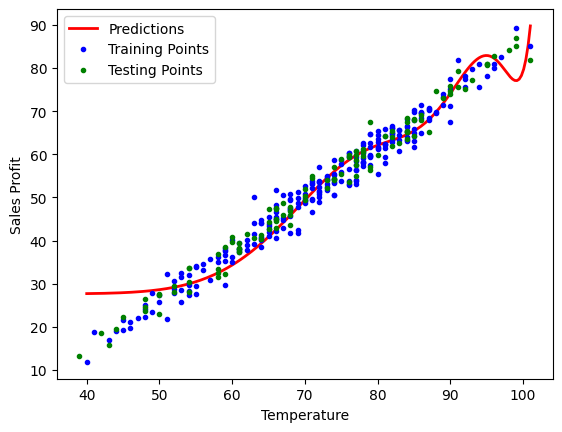

In [125]:
# plt.plot(X_train_trans, y_train, "r-", linewidth=2, label="")

plt.plot(X_new, y_new, "r-", linewidth=2, label="Predictions")
plt.plot(X_train, y_train, "b.", label="Training Points")
plt.plot(X_test, y_test, "g.", label="Testing Points")




plt.ylabel("Sales Profit")
plt.xlabel("Temperature")
plt.legend()
plt.show()


In [126]:
X_new_poly.shape

(200, 21)

In [162]:


def polynomial_regression(degree):
   
    polybig_features = PolynomialFeatures(degree=degree, include_bias=False)
    X_new=np.linspace(40,101, 200).reshape(200,1)
    X_new_poly = pd.DataFrame(polybig_features.fit_transform(X_new), columns = polybig_features.get_feature_names_out(X_train.columns))

    std_scaler = StandardScaler()
    lin_reg = LinearRegression()
    polynomial_regression = Pipeline([
        ("poly_features", polybig_features),
        ("std_scaler", std_scaler),
        ("lin_reg", lin_reg),
    ])
    polynomial_regression.fit(X_train,y_train)
    y_newbig = polynomial_regression.predict(X_new)

    plt.plot(X_new, y_newbig,'r', label="Degree " + str(degree), linewidth=2)

    plt.plot(X_train, y_train, "b.", linewidth=3)
    plt.plot(X_test, y_test, "g.", linewidth=3)
    plt.legend(loc="upper left")
    plt.xlabel("X")
    plt.ylabel("y")
    plt.axis([40, 101, 0, 11, 90])
    plt.show()

C:\Users\baps\anaconda3\envs\AnaEnv\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but PolynomialFeatures was fitted with feature names
  warnings.warn(


TypeError: The first argument to axis() must be an iterable of the form [xmin, xmax, ymin, ymax]

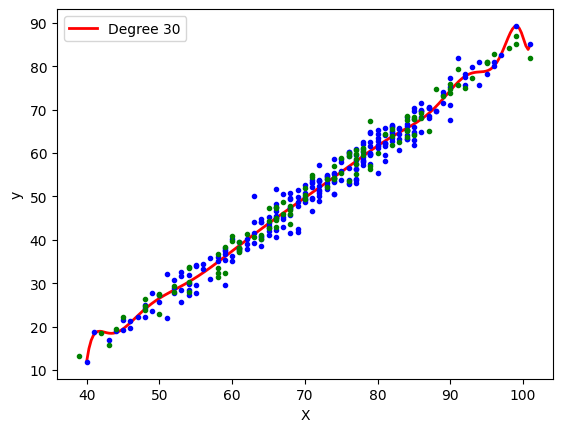

In [163]:
polynomial_regression(30)